# FDSI benchmark: apply the winning config -- pareto (wh_loss/sv_loss, median aggregation)

Applies each `lr_mode`'s (`fixed`/`rel_error`) best `AdaptConfig` found by
`03a_pareto_optimisation.ipynb`'s Pareto search (median-aggregated whitening/separation-vector
loss trade-off across the pooled recordings) to every recording in the benchmark, via the same
`AdaptDecomp.from_calibration(...).process_data(...)` call `02_fixed_adaptation.ipynb` uses for the
no-adaptation baseline -- only the `adapt_config` passed in differs.

**Load-only by default** (`RUN_APPLY_BEST=False`) -- reads the already-applied `AdaptationResult`s
under `OUTPUTS_ROOT/adaptation/<sub>/<lr_mode>/tpe_pareto/`, does not recompute them.

## Config

In [1]:
RUN_CALIBRATION = False   # compute missing calibration/<sub>/..._cbss.pkl -- needed to rebuild `calibrations` below
RUN_APPLY_BEST = False    # apply the winning config to all 100 recordings ('only those missing')

import yaml
from pathlib import Path

with open('../../configs/data_configs/fdsi_benchmark_grid.yaml') as f:
    grid = yaml.safe_load(f)

DATA_DIR = Path(grid['data_root'])           # Raw archive root: <sub>/{clean,noisy}/
OUTPUTS_ROOT = Path(grid['outputs_root'])    # Precomputed-outputs archive root
CAL_DIR, ADAPT_DIR = OUTPUTS_ROOT / 'calibration', OUTPUTS_ROOT / 'adaptation'
OPT_DIR = ADAPT_DIR / 'optimisation'

FS, EXT_FACT = grid['fs'], grid['ext_fact']
TOL_SPIKE_MS, ROA_CAL_TH = grid['tol_spike_ms'], grid['roa_cal_th']
CAL_END, ISO_DUR = int(grid['cal_duration_s'] * FS), int(grid['iso_duration_s'] * FS)

SUBJECTS, CONDITIONS, SNR_LEVELS = grid['subjects'], grid['conditions'], grid['snr_levels']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]

POOL_CONDITIONS = grid['pool_conditions']
HOLDOUT_CONDITIONS = [c for c in CONDITIONS if c not in POOL_CONDITIONS]
OPTIM_SUB, OPTIM_SNR, N_TRIALS = grid['optim_sub'], grid['optim_snr'], grid['n_trials']

BASE_CONFIG_DIR = Path('../../configs/adapt_configs')
BASE_CONFIG_PATH = BASE_CONFIG_DIR / 'default_muniverse.yaml'   # wh_sv_coupling=True; lr_mode overridden per branch below
LR_TOKEN_TO_MODE = {'lr_fixed': 'fixed', 'lr_relerror': 'rel_error'}

print(f'Apply-to-all grid: {len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels '
      f'= {len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)} recordings')

SAMPLER_NAME = 'tpe_pareto'

Apply-to-all grid: 5 subjects x 5 conditions x 4 SNR levels = 100 recordings


## Calibration

Re-derived from the on-disk cache (see `01_calibration.ipynb`) -- needed to iterate every (subject, condition, SNR) recording below.

In [2]:
import sys
sys.path.insert(0, '../..')          # package root
sys.path.insert(0, str(Path.cwd()))  # this notebook's own directory, for fdsi_common

from typing import Dict, Optional, Tuple
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

import numpy as np
from adapt_decomp import CBSS, CBSSConfig, CBSSResult
from adapt_decomp.utils import load_gt
import fdsi_common as fc


def run_calibration(sub: str, cond: str, snr: int) -> Optional[CBSSResult]:
    """Load this recording's cached calibration, or compute it if RUN_CALIBRATION is True.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.

    Returns:
        Optional[CBSSResult]: The calibration, or None if uncached and not computed, or if
            no unit matched the ground truth above ROA_CAL_TH.
    """
    result_path, config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
    if result_path.exists():
        return CBSSResult.load(result_path)
    if not RUN_CALIBRATION:
        return None

    emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
    emg_calib, ts_calib = emg_full[:CAL_END], np.arange(CAL_END) / FS
    gt_bin = load_gt(fc.gt_spikes_path(DATA_DIR, sub, cond), n_samples=CAL_END)

    cbss_config = CBSSConfig(fs=FS, ext_fact=EXT_FACT, sil_th=0.9, random_seed=42,
                              ica_iter=300, search_iter=300, save_emg=True)
    try:
        result = CBSS(cbss_config).decompose(emg_calib, ts_calib)
        result = result.select_supervised(gt_bin, roa_th=ROA_CAL_TH, tol_spike_ms=TOL_SPIKE_MS, fs=FS)
    except ValueError as exc:
        print(f'  [calibration skipped] {sub} {cond} snr{snr}dB: {exc}')
        return None

    result_path.parent.mkdir(parents=True, exist_ok=True)
    result.save(result_path)
    cbss_config.to_yaml(config_path)
    return result


calibrations: Dict[Tuple[str, str, int], Optional[CBSSResult]] = {}
pbar = tqdm(total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS), desc='Calibration')
for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            calibrations[(sub, cond, snr)] = run_calibration(sub, cond, snr)
            pbar.update(1)
pbar.close()

n_cal = sum(v is not None for v in calibrations.values())
print(f'Calibration available: {n_cal}/{len(calibrations)} recordings.')

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Calibration available: 100/100 recordings.


## Read back the winning configs

`lr_fixed` reads the config `03a_pareto_optimisation.ipynb` promoted to `configs/adapt_configs/`;
`lr_relerror` isn't promoted, so it reads back from the optimisation's own cache under
`OUTPUTS_ROOT` -- Pareto's `best_result_path` nests results per front-member trial (`trial_<N>/`), so the selection_rule's chosen trial number is re-derived from the cached study first (a pickle load, not a recompute).

In [3]:
import pickle
from adapt_decomp.adaptation import AdaptConfig

promoted_path = Path('../../configs/adapt_configs/optim_muniverse_fdsi_pareto.yaml')
best_configs = {'lr_fixed': AdaptConfig.from_yaml(promoted_path)}

with open(OPT_DIR / 'lr_relerror' / SAMPLER_NAME / 'study.pkl', 'rb') as f:
    study_relerror = pickle.load(f)
chosen_relerror = min(study_relerror.best_trials, key=lambda t: t.user_attrs['sv_loss'])
best_configs['lr_relerror'] = AdaptConfig.from_yaml(
    OPT_DIR / 'lr_relerror' / SAMPLER_NAME / f'trial_{chosen_relerror.number}' / 'config.yaml')

for lr_token, cfg in best_configs.items():
    print(f'{lr_token}: wh_learning_rate={cfg.wh_learning_rate:.4g}  sv_learning_rate={cfg.sv_learning_rate:.4g}')

lr_fixed: wh_learning_rate=0.04038  sv_learning_rate=0.002422
lr_relerror: wh_learning_rate=0.001948  sv_learning_rate=0.01728


## Apply the winning configs to the full benchmark grid

`run_adapted` below wraps the same call sequence just shown, applied once per `lr_mode` and cached
the same way as calibration.

In [4]:
import sys
sys.path.insert(0, '../..')
sys.path.insert(0, str(Path.cwd()))
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from adapt_decomp import AdaptDecomp, AdaptationResult, CBSSConfig, CBSSResult
from adapt_decomp.adaptation import AdaptConfig
from adapt_decomp.spikes import get_sil
import fdsi_common as fc


def run_adapted(sub: str, cond: str, snr: int, cbss_result: Optional[CBSSResult],
                 adapt_config: AdaptConfig, lr_mode: str,
                 sampler_name: str) -> Optional[AdaptationResult]:
    """Load this recording's cached applied-adaptation result, or compute it if RUN_APPLY_BEST is True.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.
        cbss_result (Optional[CBSSResult]): This recording's calibration, or None if
            calibration itself was skipped.
        adapt_config (AdaptConfig): The winning adaptation config to apply.
        lr_mode (str): 'fixed' or 'rel_error'.
        sampler_name (str): Search identifier, e.g. 'tpe_pareto'.

    Returns:
        Optional[AdaptationResult]: The applied result, or None if uncached/uncomputable.
    """
    if cbss_result is None:
        return None
    result_path, config_path = fc.adapted_paths(ADAPT_DIR, sub, cond, snr, lr_mode, sampler_name)
    if result_path.exists():
        return AdaptationResult.load(result_path)
    if not RUN_APPLY_BEST:
        return None

    # Get calibration config
    emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
    _, cal_config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
    cbss_config = CBSSConfig.from_yaml(cal_config_path)

    # Initialise adaptation from calibration and apply to the full recording
    adapter = AdaptDecomp.from_calibration(
        calibration=cbss_result,
        cbss_config=cbss_config,
        adapt_config=adapt_config
    )
    outputs = adapter.process_data(emg_full, preprocess=True)

    # Compute SIL and RoA
    outputs.sil = get_sil(outputs.sources, outputs.spikes, adapt_config.spike_min_dist,
                           peak_power=adapt_config.spike_det_exp).numpy()
    gt_full_bin = fc.load_gt_full_bin(DATA_DIR, sub, cond, cbss_result, n_samples=outputs.spikes.shape[0])
    outputs.roa = fc.compute_roa_for_result(outputs, gt_full_bin, FS, TOL_SPIKE_MS)

    # Save the adaptation result and config
    result_path.parent.mkdir(parents=True, exist_ok=True)
    outputs.save(result_path)
    adapt_config.to_yaml(config_path)
    return outputs


for lr_token, lr_mode in LR_TOKEN_TO_MODE.items():
    pbar = tqdm(total=len(calibrations), desc=f'Apply {lr_token}/{SAMPLER_NAME}')
    for (sub, cond, snr), cal in calibrations.items():
        run_adapted(sub, cond, snr, cal, best_configs[lr_token], lr_mode, SAMPLER_NAME)
        pbar.update(1)
    pbar.close()

print('Apply-to-all-100 pass complete (or skipped where uncached and RUN_APPLY_BEST=False).')

Apply lr_fixed/tpe_pareto:   0%|          | 0/100 [00:00<?, ?it/s]

Apply lr_relerror/tpe_pareto:   0%|          | 0/100 [00:00<?, ?it/s]

Apply-to-all-100 pass complete (or skipped where uncached and RUN_APPLY_BEST=False).


## Results

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from adapt_decomp.utils.plots import plot_metric_heatmap, plot_metric_boxplot, plot_phase_bar, plot_roa_summary_figure, plot_sources

sns.set_theme(style='whitegrid', font_scale=1.1)

### Example recording -- fixed vs adapted sources

One illustrative adaptation example (`lr_fixed`/`SAMPLER_NAME`) compared to the no-adaptation baseline `02_fixed_adaptation.ipynb`.

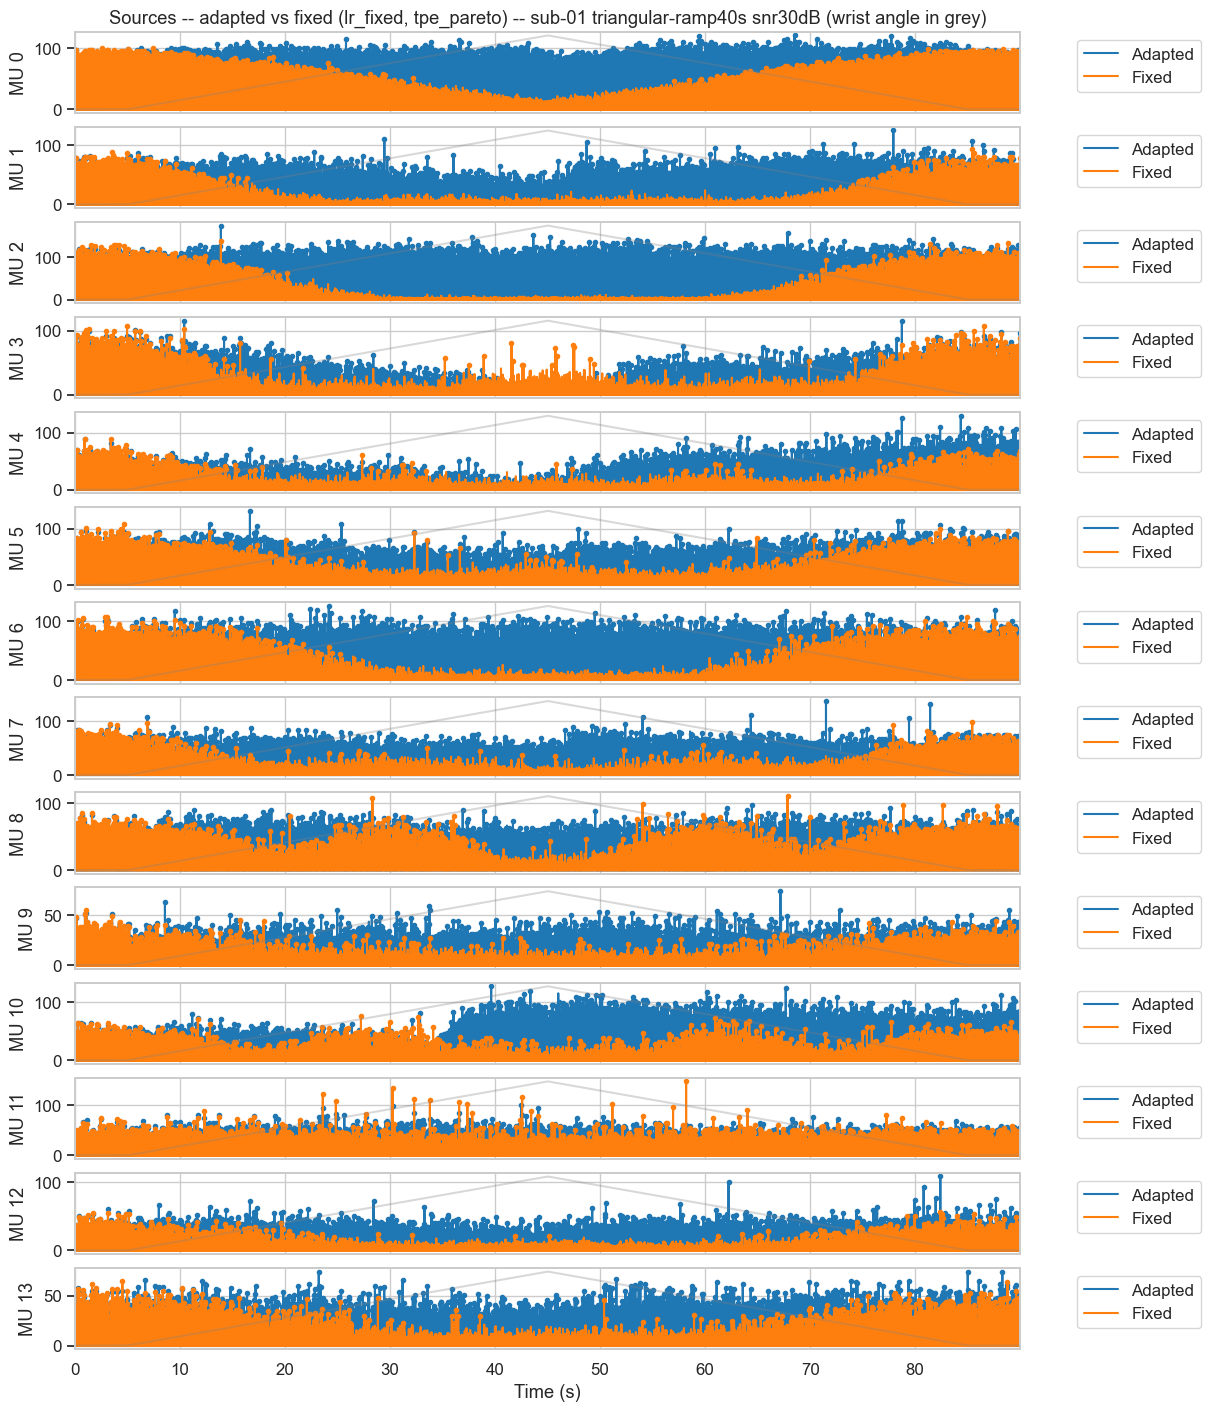

In [6]:
from adapt_decomp import AdaptationResult

sub, cond, snr = OPTIM_SUB, TRIANGULAR[0], OPTIM_SNR
fixed_result_path, _ = fc.fixed_paths(ADAPT_DIR, sub, cond, snr)
adapted_result_path, _ = fc.adapted_paths(ADAPT_DIR, sub, cond, snr, lr_mode='fixed', sampler_name=SAMPLER_NAME)
fixed_outputs = AdaptationResult.load(fixed_result_path)
adapted_outputs = AdaptationResult.load(adapted_result_path)
angle = fc.load_angle_profile(DATA_DIR, sub, cond)
ts_full = np.arange(fixed_outputs.spikes.shape[0]) / FS
TIME_RANGE = (0, ts_full[-1])

axs = plot_sources(
    sources={'Adapted': adapted_outputs.sources.numpy(), 'Fixed': fixed_outputs.sources.numpy()},
    timestamps=ts_full,
    spikes={'Adapted': adapted_outputs.spikes.numpy(), 'Fixed': fixed_outputs.spikes.numpy()},
    time_range=TIME_RANGE,
    square_sources=True,
)
for ax in axs:
    ax_angle = ax.twinx()
    ax_angle.plot(ts_full, angle, color='grey', alpha=0.3, zorder=0)
    ax_angle.set_yticks([])
axs[0].set_title(f'Sources -- adapted vs fixed (lr_fixed, {SAMPLER_NAME}) -- {sub} {cond} snr{snr}dB (wrist angle in grey)')
plt.show()

### Heatmaps -- mean / median / % good units RoA, and SIL if cached (guarded on whatever `RUN_APPLY_BEST` has already produced on disk)

In [7]:
CONFIG_LABELS = [('fixed', None, None)]
for lr_token, lr_mode in LR_TOKEN_TO_MODE.items():
    CONFIG_LABELS.append((f'{lr_token}_{SAMPLER_NAME}', lr_mode, SAMPLER_NAME))
CONFIG_ORDER = [c for c, _, _ in CONFIG_LABELS]

In [8]:
df_roa = fc.aggregate_roa_from_disk(ADAPT_DIR, CAL_DIR, DATA_DIR, SUBJECTS, CONDITIONS, SNR_LEVELS,
                                     CONFIG_LABELS, FS, TOL_SPIKE_MS)
if len(df_roa):
    df_roa['roa_pct'] = df_roa['roa'] * 100
    configs_present = [c for c in CONFIG_ORDER if c in df_roa['config'].unique()]
    print(f'{len(df_roa)} (recording, unit, config) rows aggregated from disk.')
else:
    configs_present = []

2304 (recording, unit, config) rows aggregated from disk.


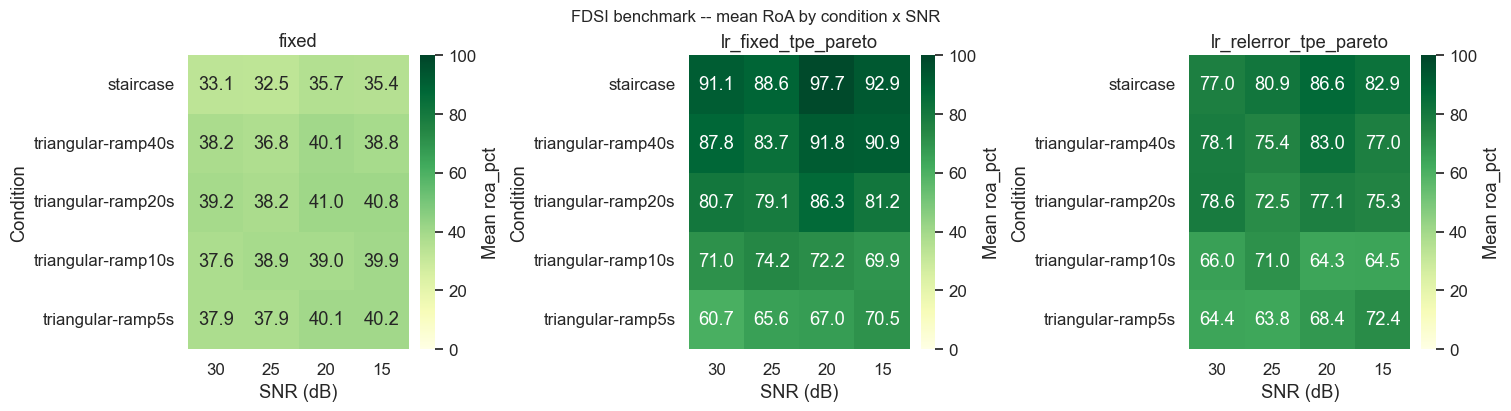

In [9]:
if len(df_roa):
    plot_metric_heatmap(
        df_roa, 'roa_pct', configs_present, CONDITIONS, SNR_LEVELS,
        agg='mean', vmin=0, vmax=100
    )
    plt.suptitle('FDSI benchmark -- mean RoA by condition x SNR', fontsize=12)
    plt.show()

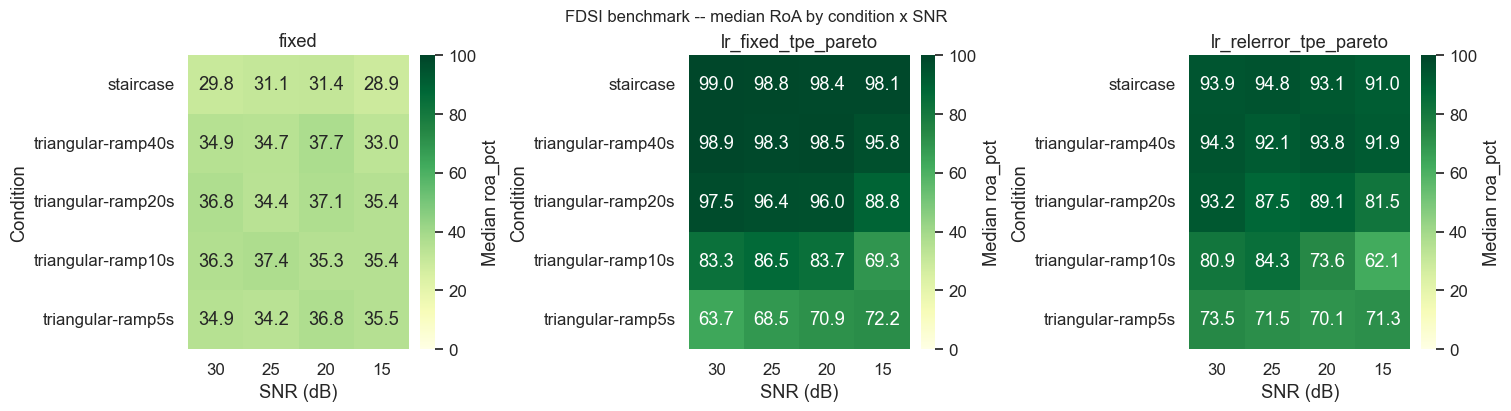

In [10]:
if len(df_roa):
    plot_metric_heatmap(
        df_roa, 'roa_pct', configs_present, CONDITIONS, SNR_LEVELS,
        agg='median', vmin=0, vmax=100
    )
    plt.suptitle('FDSI benchmark -- median RoA by condition x SNR', fontsize=12)
    plt.show()

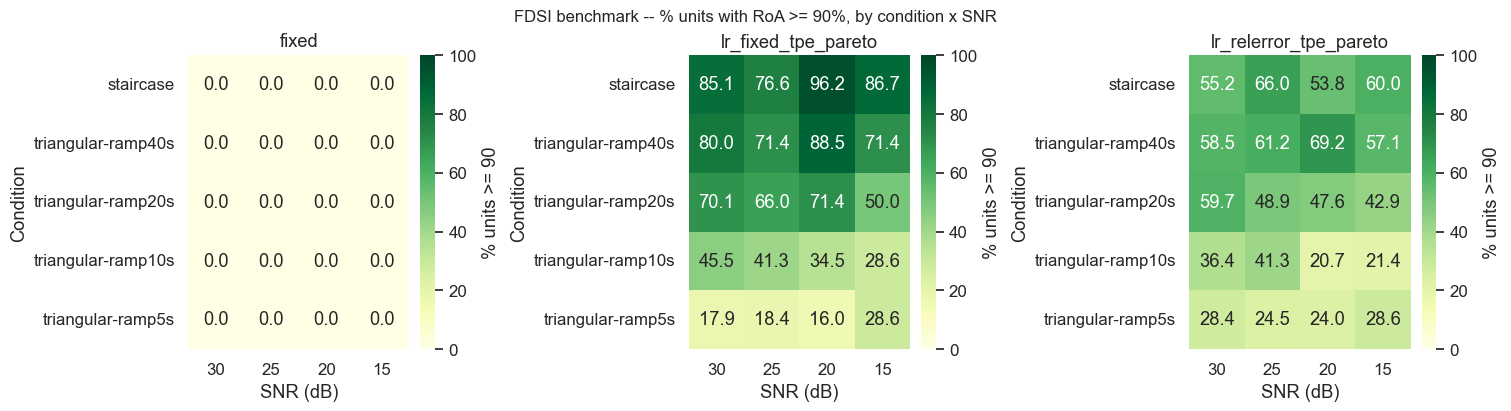

In [11]:
if len(df_roa):
    plot_metric_heatmap(
        df_roa, 'roa_pct', configs_present, CONDITIONS, SNR_LEVELS,
        agg='pct_ge_threshold', threshold=90.0, vmin=0, vmax=100
    )
    plt.suptitle('FDSI benchmark -- % units with RoA >= 90%, by condition x SNR', fontsize=12)
    plt.show()

In [12]:
df_sil = fc.aggregate_sil_from_disk(ADAPT_DIR, CAL_DIR, SUBJECTS, CONDITIONS, SNR_LEVELS, CONFIG_LABELS)
if len(df_sil):
    print(f'{len(df_sil)} (recording, unit, config) SIL rows aggregated from disk.')

2304 (recording, unit, config) SIL rows aggregated from disk.


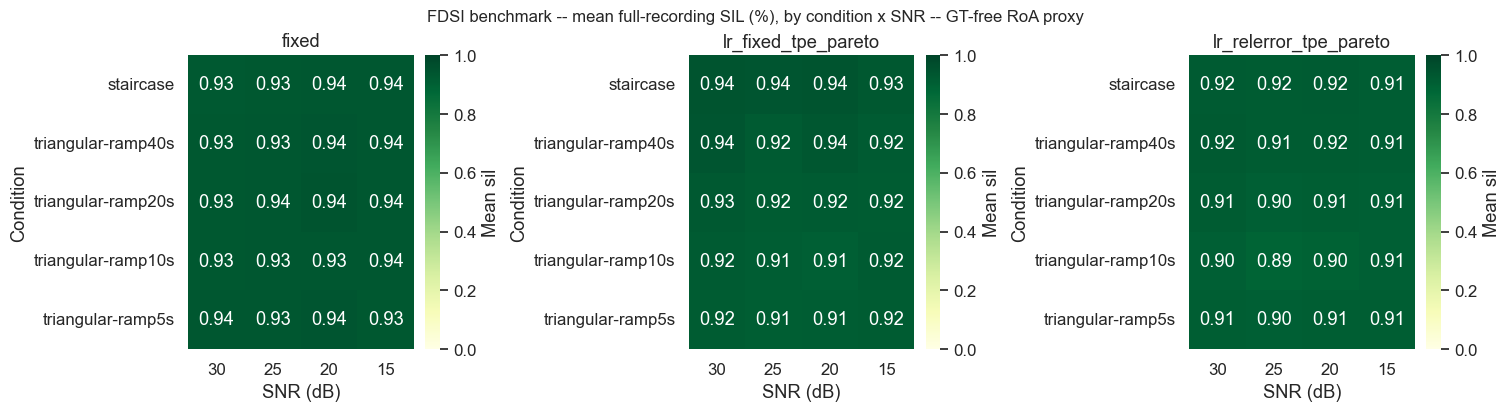

In [13]:
if len(df_sil):
    plot_metric_heatmap(
        df_sil, 'sil', configs_present, CONDITIONS, SNR_LEVELS,
        agg='mean', vmin=0, vmax=1)
    plt.suptitle('FDSI benchmark -- mean full-recording SIL (%), by condition x SNR -- GT-free RoA proxy', fontsize=12)
    plt.show()

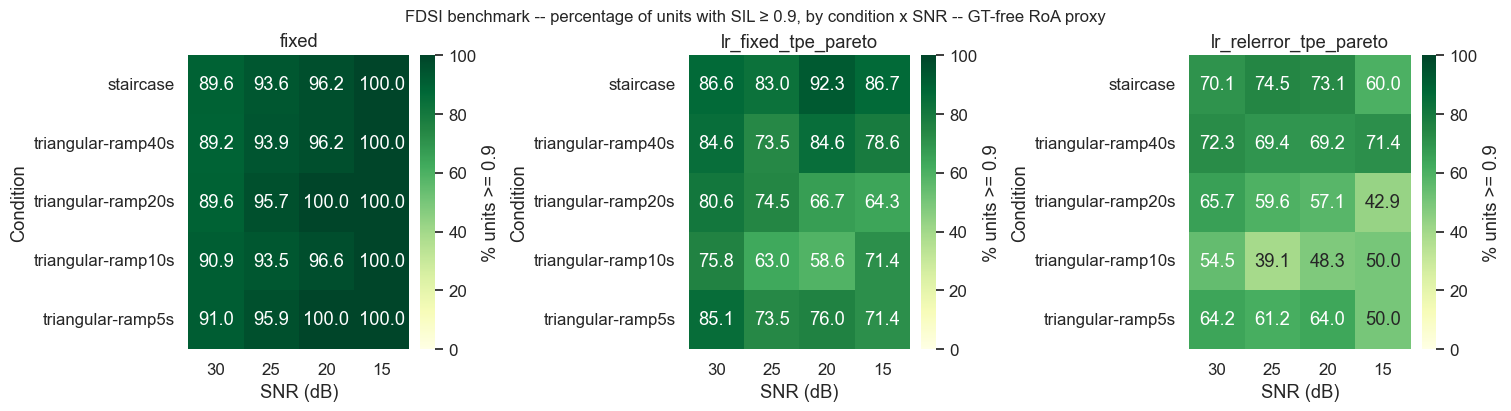

In [14]:
if len(df_sil):
    plot_metric_heatmap(
        df_sil, 'sil', configs_present, CONDITIONS, SNR_LEVELS,
        agg='pct_ge_threshold', threshold=0.9,
        vmin=0, vmax=100
    )
    plt.suptitle('FDSI benchmark -- percentage of units with SIL ≥ 0.9, by condition x SNR -- GT-free RoA proxy', fontsize=12)
    plt.show()

### Boxplots -- per-unit RoA distribution by condition, hue=SNR

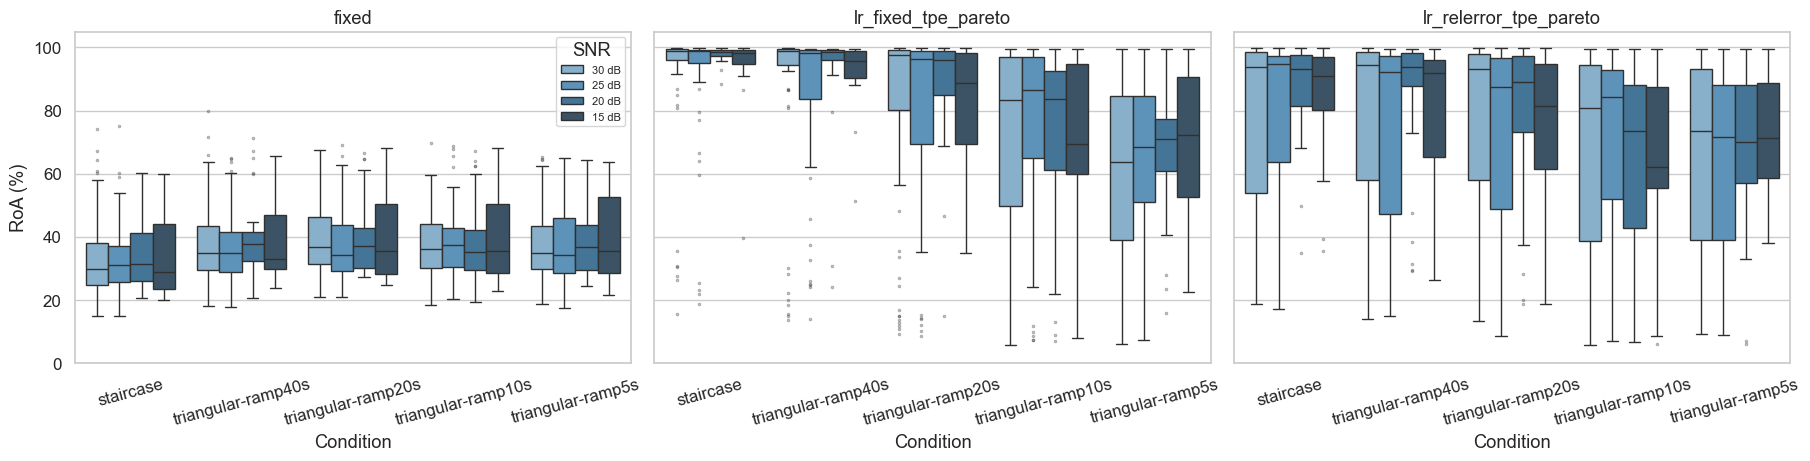

In [15]:
if len(df_roa):
    axs =plot_metric_boxplot(
        df_roa, 'roa_pct', configs_present, CONDITIONS, SNR_LEVELS,
        vmin=0, vmax=105
    )
    axs[0].set(ylabel='RoA (%)')
    plt.show()

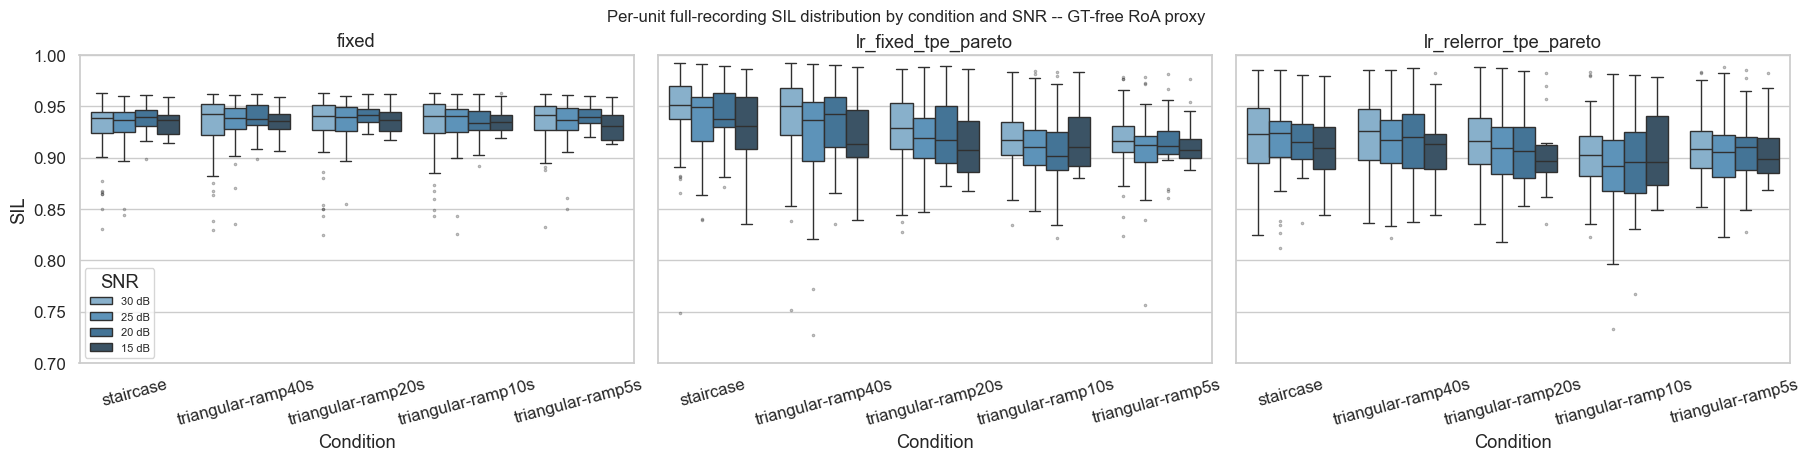

In [16]:
if len(df_sil):
    axs = plot_metric_boxplot(
        df_sil, 'sil', configs_present, CONDITIONS, SNR_LEVELS,
        vmin=0.7, vmax=1
    )
    axs[0].set(ylabel='SIL')
    plt.suptitle('Per-unit full-recording SIL distribution by condition and SNR -- GT-free RoA proxy', fontsize=12)
    plt.show()

### Final combined figure -- RoA line trend + phase bars, pool vs holdout

In [17]:
df_phase = fc.aggregate_phase_roa_from_disk(ADAPT_DIR, CAL_DIR, DATA_DIR, SUBJECTS, TRIANGULAR,
                                             SNR_LEVELS, CONFIG_LABELS, FS, TOL_SPIKE_MS, CAL_END, ISO_DUR)
print(f'Phase-RoA rows: {len(df_phase)}')

Phase-RoA rows: 5517


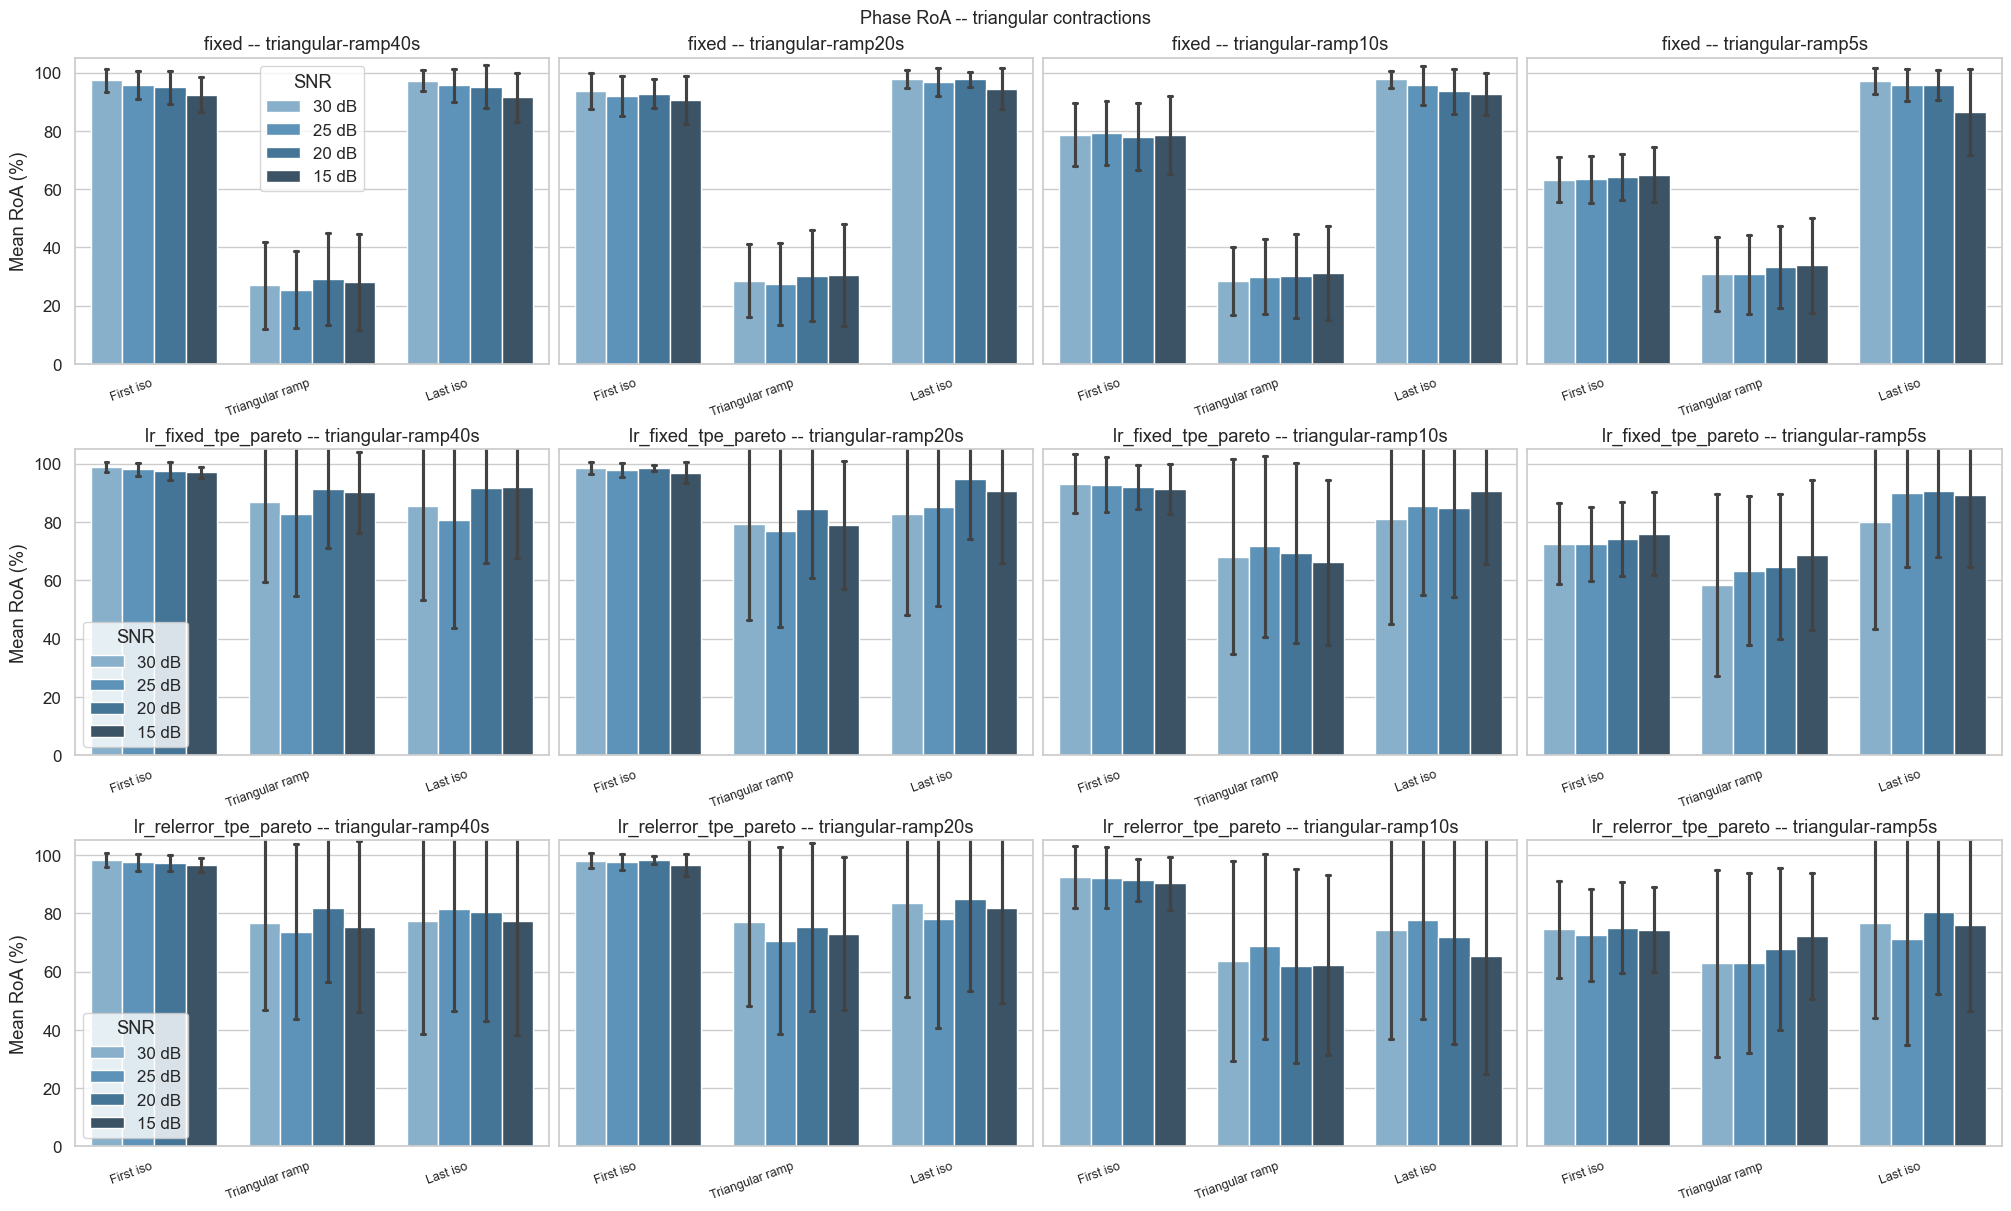

In [18]:
if len(df_phase):
    plot_phase_bar(df_phase, configs_present, TRIANGULAR, SNR_LEVELS, fc.PHASE_ORDER, fc.PHASE_LABELS)
    plt.suptitle('Phase RoA -- triangular contractions', fontsize=13)
    plt.show()

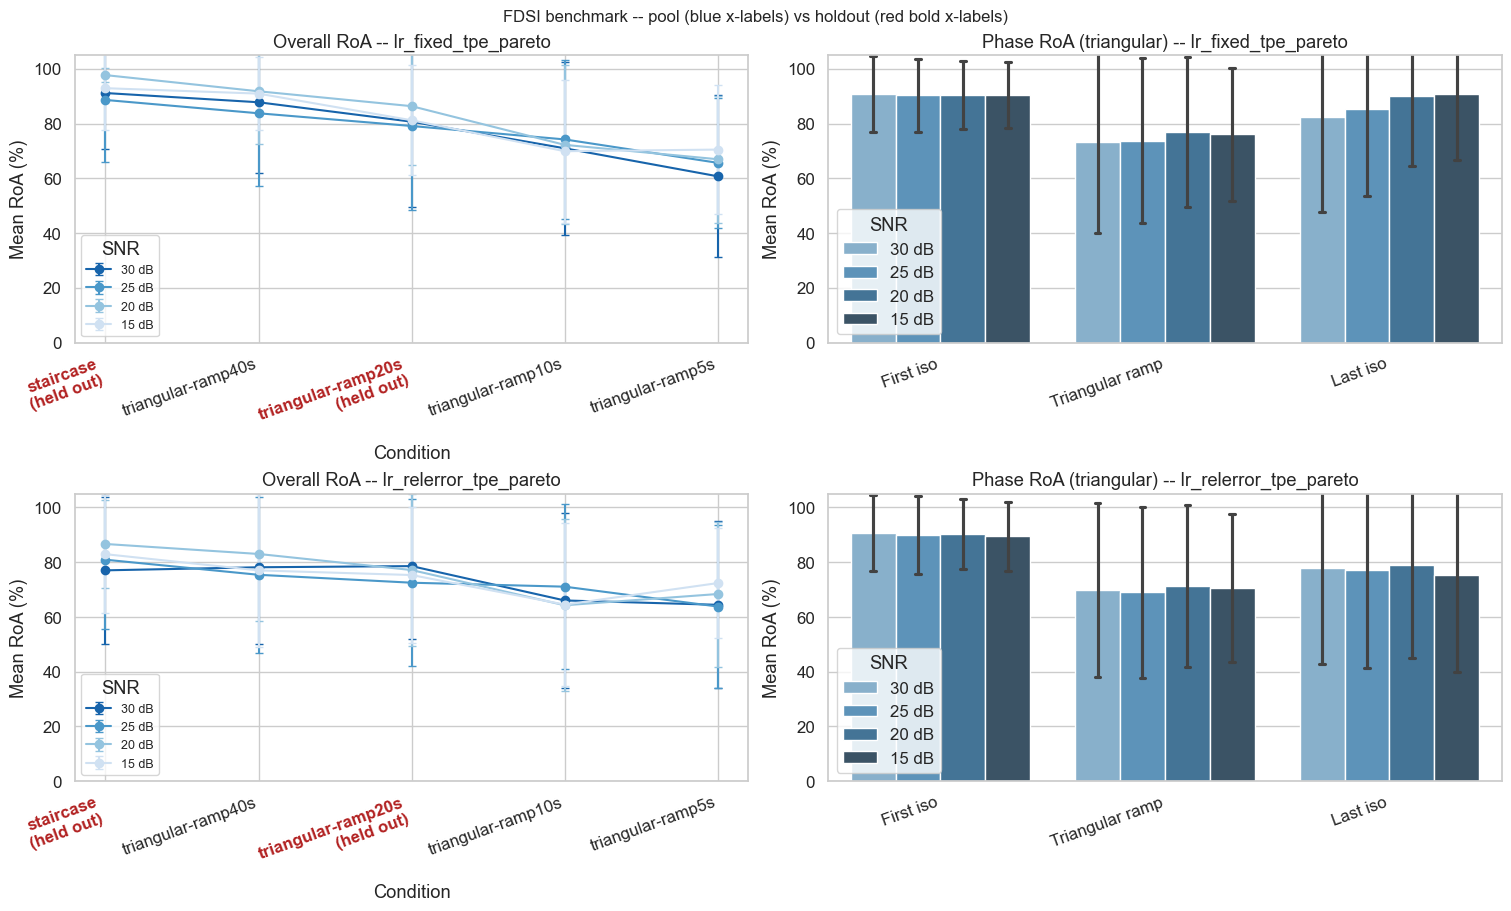

In [19]:
if len(df_roa) and len(df_phase):
    adapted_labels = [c for c, lr, s in CONFIG_LABELS if lr is not None and c in configs_present]
    plot_roa_summary_figure(df_roa, df_phase, adapted_labels, CONDITIONS, HOLDOUT_CONDITIONS,
                             SNR_LEVELS, fc.PHASE_ORDER, fc.PHASE_LABELS)
    plt.suptitle('FDSI benchmark -- pool (blue x-labels) vs holdout (red bold x-labels)', fontsize=12)
    plt.show()